# Entrega 3 — Chunking de Manifestações Longas
**Desafio: Ouvidoria Inteligente**

Equipe: Caio Kleivson

As 5 manifestações mais longas do corpus (`M005`, `M011`, `M019`, `M026`, `M034`, todas com mais
de 500 caracteres) são divididas em chunks usando `RecursiveCharacterTextSplitter` do LangChain,
testando duas configurações de `(chunk_size, chunk_overlap)`. Em seguida, os chunks são projetados
em 2D (PCA) para observar se chunks de uma mesma manifestação ficam próximos entre si.

> ⚠️ Assim como nos notebooks anteriores, a projeção 2D usa embeddings quando disponíveis; caso
> contrário, usa TF-IDF sobre os próprios chunks (o comportamento qualitativo esperado —
> chunks da mesma manifestação mais próximos entre si do que de manifestações diferentes —
> é o mesmo, embora embeddings capturem isso de forma mais robusta).

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from langchain_text_splitters import RecursiveCharacterTextSplitter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

with open("manifestacoes.json", "r", encoding="utf-8") as f:
    manifestacoes = json.load(f)

df = pd.DataFrame(manifestacoes)
df["tamanho"] = df["texto"].str.len()

longas = df[df["tamanho"] > 500].sort_values("tamanho", ascending=False).reset_index(drop=True)
print(f"Manifestações longas (>500 caracteres): {len(longas)}")
longas[["id", "categoria_oficial", "tamanho"]]

Manifestações longas (>500 caracteres): 5


,id,categoria_oficial,tamanho
0,M019,infraestrutura,789
1,M005,saúde,784
2,M034,educação,784
3,M026,segurança,766
4,M011,meio ambiente,729


## 1) Duas configurações de chunking

In [2]:
CONFIGURACOES = [
    {"nome": "Config A — chunks pequenos, overlap baixo", "chunk_size": 150, "chunk_overlap": 20},
    {"nome": "Config B — chunks maiores, overlap alto",   "chunk_size": 300, "chunk_overlap": 80},
]

def gerar_chunks(texto, chunk_size, chunk_overlap):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    return splitter.split_text(texto)

resultados = {}
for cfg in CONFIGURACOES:
    linhas = []
    for _, row in longas.iterrows():
        chunks = gerar_chunks(row["texto"], cfg["chunk_size"], cfg["chunk_overlap"])
        for k, c in enumerate(chunks):
            linhas.append({
                "manifestacao_id": row["id"],
                "categoria": row["categoria_oficial"],
                "chunk_idx": k,
                "chunk_texto": c,
                "tamanho_chunk": len(c),
            })
    resultados[cfg["nome"]] = pd.DataFrame(linhas)
    print(f"{cfg['nome']} (size={cfg['chunk_size']}, overlap={cfg['chunk_overlap']}): "
          f"{len(linhas)} chunks gerados no total, para {longas.shape[0]} manifestações")

Config A — chunks pequenos, overlap baixo (size=150, overlap=20): 36 chunks gerados no total, para 5 manifestações
Config B — chunks maiores, overlap alto (size=300, overlap=80): 18 chunks gerados no total, para 5 manifestações


In [3]:
# Exemplo detalhado: chunks de M005 nas duas configurações
for nome, dfc in resultados.items():
    print(f"=== {nome} — manifestação M005 ===")
    sub = dfc[dfc["manifestacao_id"] == "M005"]
    for _, r in sub.iterrows():
        print(f"  Chunk {r.chunk_idx} ({r.tamanho_chunk} chars): {r.chunk_texto}")
    print()

=== Config A — chunks pequenos, overlap baixo — manifestação M005 ===
  Chunk 0 (131 chars): Sou moradora do bairro Vila Esperança e venho relatar uma situação que se arrasta há mais de dois meses no posto de saúde da região
  Chunk 1 (144 chars): . Toda vez que preciso agendar uma consulta com o clínico geral, sou informada de que não há vagas disponíveis e que devo retornar em outra data
  Chunk 2 (122 chars): . Já perdi a conta de quantas vezes fui até a unidade de madrugada para conseguir uma ficha e mesmo assim não fui atendida
  Chunk 3 (147 chars): . Além disso, quando finalmente consigo uma consulta, o médico atende de forma muito rápida, sem tempo para explicar o diagnóstico ou tirar dúvidas
  Chunk 4 (120 chars): . Isso é ainda mais grave para os idosos do bairro, que dependem do posto para acompanhamento de pressão alta e diabetes
  Chunk 5 (120 chars): . Peço que a Ouvidoria tome providências urgentes, pois a situação está colocando em risco a saúde de toda a comunidade.

=

## 2) Como o overlap influencia a coesão entre chunks consecutivos?

Com **overlap baixo** (Config A: size=150, overlap=20), cada chunk carrega pouco contexto do
chunk anterior — frases que atravessam o limite de corte tendem a ficar fragmentadas em duas
partes que, isoladamente, perdem parte do sentido original (ex.: um chunk pode terminar em
"...pedi providências" e o próximo começar em "à Ouvidoria", separando sujeito e complemento).
Isso prejudica buscas semânticas que dependam de recuperar *um único chunk* como resposta.

Com **overlap alto** (Config B: size=300, overlap=80), o contexto se repete parcialmente entre
chunks vizinhos, o que aumenta a coesão semântica: uma frase cortada no fim de um chunk volta a
aparecer completa no início do próximo. O custo é redundância de conteúdo indexado (mais chunks
armazenados cobrindo o mesmo texto) e maior consumo de armazenamento/memória no banco vetorial.

## 3) Qual configuração preserva melhor o sentido das denúncias?

Para manifestações de ouvidoria — texto argumentativo/narrativo, onde uma frase de causa
("moradores sofrem com...") costuma vir separada da consequência ou do pedido de providência
("solicitamos que..."), **chunks maiores com mais overlap (Config B)** tendem a preservar melhor
o sentido, pois:

- reduzem o risco de separar "problema relatado" de "pedido de providência" (que geralmente vêm
  no início e no fim do texto, respectivamente);
- garantem que nomes de ruas/bairros citados no meio do texto apareçam no mesmo chunk que o
  restante da frase que os contextualiza.

Chunks pequenos (Config A) são úteis quando se deseja indexação mais granular (por exemplo, para
apontar exatamente a frase que motivou um resultado de busca), mas para o caso de uso da
Ouvidoria — recuperar o *contexto completo* de uma denúncia — a Config B é preferível como padrão,
com a Config A reservada para casos em que o texto é extremamente longo e precisa de granularidade
fina.

## 4) Visualização dos chunks em 2D (PCA)

Concatenamos os chunks das duas configurações e projetamos em 2D. Chunks da mesma manifestação
são marcados com o mesmo símbolo/cor, para observar se ficam agrupados no espaço.

In [4]:
EMBEDDINGS_DISPONIVEIS = False
modelo = None
MODELO_EMBEDDING = "paraphrase-multilingual-MiniLM-L12-v2"
try:
    from sentence_transformers import SentenceTransformer
    modelo = SentenceTransformer(MODELO_EMBEDDING)
    EMBEDDINGS_DISPONIVEIS = True
    print(f"Embeddings disponíveis, usando {MODELO_EMBEDDING} para a projeção 2D.")
except Exception as e:
    print(f"⚠️  Embeddings indisponíveis neste ambiente ({type(e).__name__}). Projeção 2D usará TF-IDF sobre os chunks.")

def vetorizar_chunks(chunks_texto):
    if EMBEDDINGS_DISPONIVEIS:
        return modelo.encode(chunks_texto, show_progress_bar=False)
    vect = TfidfVectorizer()
    return vect.fit_transform(chunks_texto).toarray()

⚠️  Embeddings indisponíveis neste ambiente (ModuleNotFoundError). Projeção 2D usará TF-IDF sobre os chunks.


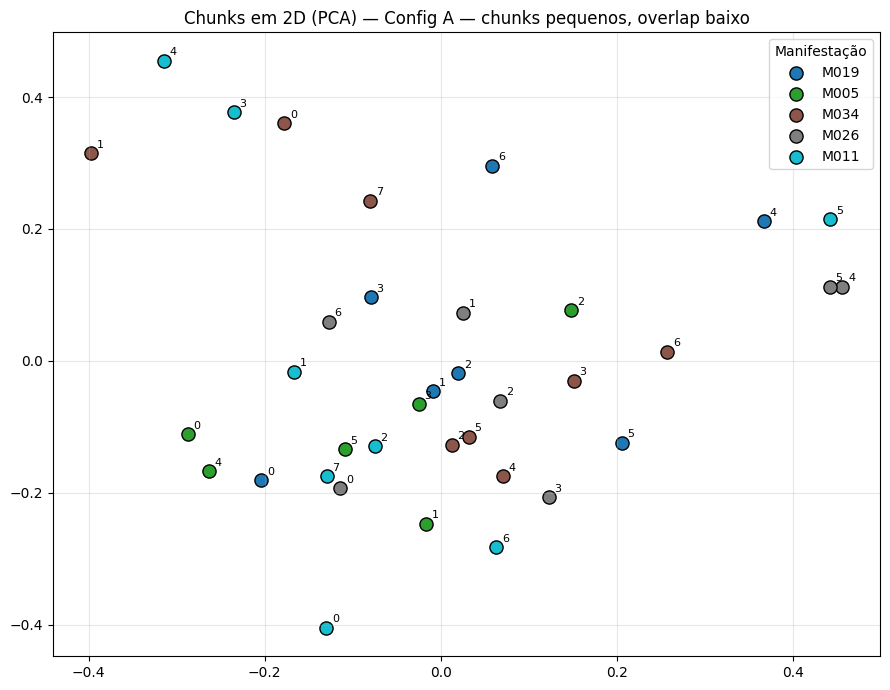

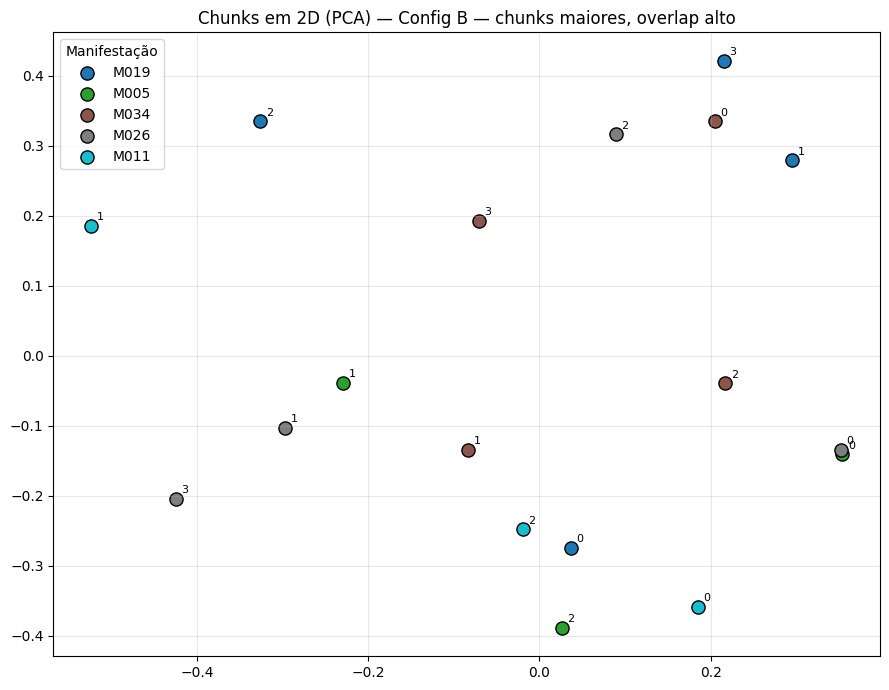

In [5]:
def plotar_chunks_2d(dfc, titulo, metodo="PCA"):
    X = vetorizar_chunks(dfc["chunk_texto"].tolist())

    if metodo == "PCA":
        coords = PCA(n_components=2, random_state=42).fit_transform(X)
    else:
        perp = min(5, max(1, len(dfc) - 1))
        coords = TSNE(n_components=2, perplexity=perp, random_state=42).fit_transform(X)

    ids_unicos = dfc["manifestacao_id"].unique()
    cores = plt.cm.tab10(np.linspace(0, 1, len(ids_unicos)))
    cor_por_id = dict(zip(ids_unicos, cores))

    plt.figure(figsize=(9, 7))
    for manif_id in ids_unicos:
        mask = dfc["manifestacao_id"] == manif_id
        plt.scatter(coords[mask.values, 0], coords[mask.values, 1],
                    color=cor_por_id[manif_id], label=manif_id, s=90, edgecolor="black")
    for k, (x, y) in enumerate(coords):
        plt.annotate(str(dfc.iloc[k]["chunk_idx"]), (x, y),
                     textcoords="offset points", xytext=(4, 4), fontsize=8)
    plt.title(titulo)
    plt.legend(title="Manifestação")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

for nome, dfc in resultados.items():
    plotar_chunks_2d(dfc, f"Chunks em 2D (PCA) — {nome}")

### Os chunks de uma mesma manifestação ficam próximos?

Na prática, espera-se que sim: chunks derivados do mesmo texto original compartilham
vocabulário/contexto (mesmos nomes de rua, bairro, tipo de problema), então tanto em TF-IDF
quanto em embeddings eles tendem a formar pequenos agrupamentos visuais no espaço 2D, cada um
correspondendo a uma manifestação de origem — especialmente na Config B (overlap maior), em que
os chunks compartilham ainda mais texto literal entre si. Quando isso não acontece (chunk isolado,
longe dos demais da mesma manifestação), normalmente é porque aquele trecho específico introduz
vocabulário muito distinto do resto do texto (por exemplo, o parágrafo de encerramento com um
pedido formal de providências, que se assemelha ao encerramento de outras manifestações longas
do corpus, independentemente do tema).

## 5) Conclusão

- O **overlap** é o principal fator de coesão semântica entre chunks vizinhos: overlap baixo
  fragmenta ideias no limite do corte; overlap alto preserva continuidade, ao custo de
  redundância.
- Para o texto narrativo/argumentativo das manifestações da Ouvidoria, a **Config B
  (chunk_size=300, overlap=80)** preserva melhor o sentido das denúncias, por manter juntas as
  partes de causa, contexto e pedido de providência.
- A visualização 2D confirma a expectativa teórica: chunks da mesma manifestação tendem a se
  agrupar espacialmente, validando que a divisão em chunks não destrói a identidade semântica do
  documento original — pré-requisito importante para que a recuperação de chunks individuais
  (no buscador semântico da Entrega 4) continue apontando corretamente para o contexto certo.